In [ ]:
# Example of how to use the trained model for prediction

# Let's say we have a new house with the following features:
new_house_features = pd.DataFrame({
    'SquareFootage': [2500],
    'Bedrooms': [4],
    'Bathrooms': [3]
})

# Make a prediction using the trained model
predicted_price = model.predict(new_house_features)

print(f"Features of the new house:\n{new_house_features}")
print(f"Predicted price for the new house: ${predicted_price[0]:,.2f}")

Features of the new house:
   SquareFootage  Bedrooms  Bathrooms
0           2500         4          3
Predicted price for the new house: $313,392.90


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Generate a synthetic dataset
np.random.seed(42)
num_samples = 100

square_footage = np.random.randint(1000, 3500, num_samples)
bedrooms = np.random.randint(2, 6, num_samples)
bathrooms = np.random.randint(1, 4, num_samples)

# Simulate price with some noise
price = 50 * square_footage + 30000 * bedrooms + 20000 * bathrooms + np.random.normal(0, 50000, num_samples)

data = pd.DataFrame({
    'SquareFootage': square_footage,
    'Bedrooms': bedrooms,
    'Bathrooms': bathrooms,
    'Price': price
})

display(data.head())

,SquareFootage,Bedrooms,Bathrooms,Price
0,1860,3,3,336288.725557
1,2294,2,2,238391.646046
2,2130,5,3,256934.825140
3,2095,4,3,317577.680432
4,2638,4,2,243165.916489


Now that we have our synthetic dataset, let's prepare it for the linear regression model. We'll split the data into training and testing sets.

In [ ]:
# Define features (X) and target (y)
X = data[['SquareFootage', 'Bedrooms', 'Bathrooms']]
y = data['Price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 80 samples
Test set size: 20 samples


Next, we will train a linear regression model using the training data and then evaluate its performance on the test set.

In [ ]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Model Coefficients: [   50.28791004 31229.64470029 22221.44312807]
Model Intercept: -3909.783356267202
Mean Squared Error: 3551402737.60
R-squared: 0.29


Finally, let's visualize the actual vs. predicted prices to get a better understanding of the model's performance.

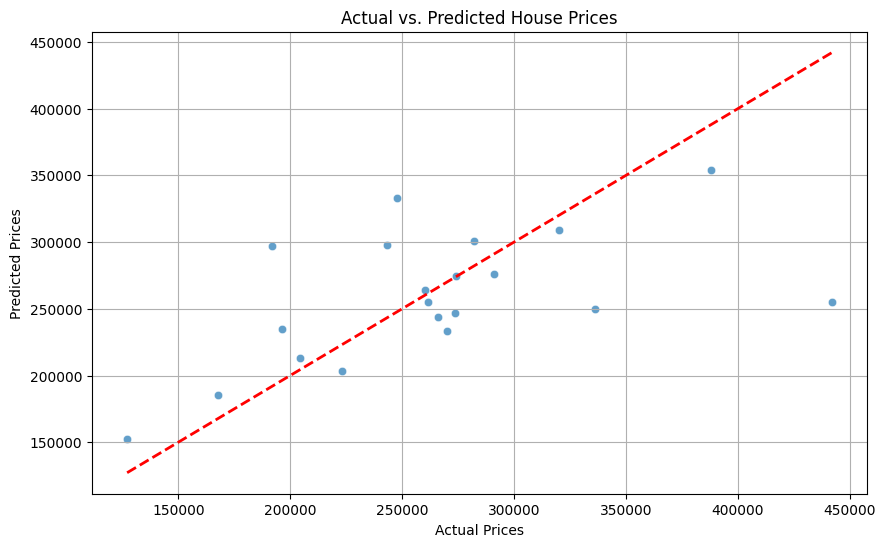

In [ ]:
# Visualize predictions vs actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted House Prices")
plt.grid(True)
plt.show()